In [1]:
import os
import pandas as pd
from tqdm import tqdm
import logging
import requests
from SPARQLWrapper import SPARQLWrapper, JSON
import nest_asyncio
import random
import json
import aiohttp
import asyncio
import backoff

In [2]:
R3_json_file_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/_Round3/R3_NER_query_type.json"

with open(R3_json_file_path, "r") as file:
    R3_ner_type = json.load(file)

R3_json_file_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/_Round3/R3_WD_query_type.json"

with open(R3_json_file_path, "r") as file:
    R3_explicit_type = json.load(file)

R3_tables_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round3_2019/tables/"
R3_cea_file = '/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round3_2019/gt/CEA_Round3_gt_WD.csv'
R3_cta_file = '/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round3_2019/gt/CTA_Round3_gt.csv'


In [3]:

os.listdir(R3_tables_path)
# Initialize logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Read the cea_file and create a key-value dictionary
df_cea = pd.read_csv(R3_cea_file, header=None)
df_cea["key"] = df_cea[0] + " " + df_cea[1].astype(str) + " " + df_cea[2].astype(str)
df_cea["key_col"] = df_cea[0] + " " + df_cea[2].astype(str)
cea_values_dict = dict(zip(df_cea["key_col"].values, df_cea[3].values))

cea_keys_set = set(df_cea["key"].values)
cea_values_dict_cell = dict(zip(df_cea["key"].values, df_cea[3].values))

# Function to process a single table file
def process_table_file(table_file):
    try:
        table_name = os.path.splitext(os.path.basename(table_file))[0]
        df = pd.read_csv(table_file)
        qid_to_value = {}

        for row in range(df.shape[0]):
            for col in range(df.shape[1]):
                key = f"{table_name} {row+1} {col}"
                if key in cea_keys_set:
                    cell_value = df.iloc[row, col]
                    qid = cea_values_dict_cell[key].split('/')[-1]  # Extract the QID from the URL
                    qid_to_value[cell_value] = qid
                    break  # Exit inner loop early as only one match per row/col is needed

        return qid_to_value
    except Exception as e:
        logging.error(f"Error processing {table_file}: {e}")
        return {}

# List of table files
table_files = [
    os.path.join(R3_tables_path, table)
    for table in os.listdir(R3_tables_path)
    if not table.startswith('.')
]

# Process tables sequentially
R3_id_to_name = {}
for table_file in tqdm(table_files, desc="Processing tables"):
    local_key_to_cell = process_table_file(table_file)
    R3_id_to_name.update(local_key_to_cell)

Processing tables: 100%|██████████| 2161/2161 [00:06<00:00, 342.22it/s]


## NER type vs NER type

In [4]:
def get_hard_query_ner_to_ner(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:

        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}},
                        {"terms": {"NERtype": [value]}}  # Ensures `value` matches at least one in the array
                    ]
                }
            }
        }
        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
    return params

def get_soft_query_ner_to_ner(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"NERtype": value}}]
        else:
            should_clause = [{"term": {"NERtype": value}}]

    query_dict = {
        "query": {
            "bool": {
                "must": [
                    {"match": {"name": {"query": name, "boost": 2.0}}}
                ],
                "should": should_clause
            }
        }
    }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params

In [5]:
queries_ner_to_ner_HARD = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"HARD ner_to_ner: processing R3"):
    if id in R3_ner_type:
        types_list = R3_ner_type[id]      
        query = get_hard_query_ner_to_ner(name, types_list)
        if query is None:
            continue
        queries_ner_to_ner_HARD.append((query, id, types_list))


queries_ner_to_ner_SOFT = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"SOFT ner_to_ner: processing R3"):
    if id in R3_ner_type:
        types_list = R3_ner_type[id]      
        query = get_soft_query_ner_to_ner(name, types_list)
        queries_ner_to_ner_SOFT.append((query, id, types_list))


SOFT ner_to_ner: processing R3: 100%|██████████| 101846/101846 [00:00<00:00, 1752030.57it/s]


In [6]:
failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=60) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar):
    try:
        data = await fetch(session, url, params, headers, semaphore)
    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0

    
    #print(f"------------>{eval(params['query'])['query']['bool']['must'][1]} - # candidate: {len(data)}")
    if data:
        for item in data:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

    return 0, 0

async def main(queries, url, pbar, failed_queries):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar))
        
        results = await asyncio.gather(*tasks)
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # redo the same query with the fuzzy
                name = param['name']
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                m_mrr += mrr_increment
                cont_el += count 
            else:
                m_mrr += mrr_increment
                cont_el += count

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"---------------> Coverage of R3 for queries_ner_to_ner: {cont_el / len(queries)}")
    print(f"---------------> Measure Reciprocal Rank of R3 for queries_ner_to_ner: {m_mrr / len(queries)}")


nest_asyncio.apply()  # Apply nest_asyncio
print("_________HARD____________")
try:
    if len(queries_ner_to_ner_HARD) >= 1000:
        queries = random.sample(queries_ner_to_ner_HARD, 1000)
    else:
        queries = queries_ner_to_ner_HARD
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

print("_________SOFT____________")
try:
    if len(queries_ner_to_ner_SOFT) >= 1000:
        queries = random.sample(queries_ner_to_ner_SOFT, 1000)
    else:
        queries = queries_ner_to_ner_SOFT
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

_________HARD____________


 10%|█         | 103/1000 [03:10<27:39,  1.85s/it]  


---------------> Coverage of R3 for queries_ner_to_ner: 0.102
---------------> Measure Reciprocal Rank of R3 for queries_ner_to_ner: 0.09657099999999989
_________SOFT____________


 12%|█▏        | 121/1000 [02:57<21:28,  1.47s/it]  

---------------> Coverage of R3 for queries_ner_to_ner: 0.12
---------------> Measure Reciprocal Rank of R3 for queries_ner_to_ner: 0.10959799999999985


## explicit VS extended WD TYPES

In [7]:
def get_hard_query_explicit_to_extended(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:

        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}},
                        {"terms": {"extended_WDtypes": [value]}}  # Ensures `value` matches at least one in the array
                    ]
                }
            }
        }
        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
        return params
    return None

def get_soft_query_explicit_to_extended(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"extended_WDtypes": v}} for v in value]
        else:
            should_clause = [{"term": {"extended_WDtypes": value}}]

    query_dict = {
        "query": {
            "bool": {
                "must": [
                    {"match": {"name": {"query": name, "boost": 2.0}}}
                ],
                "should": should_clause
            }
        }
    }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params

In [8]:
queries_explicit_to_extended_HARD = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"HARD expl_to_extend: processing R3"):
    if id in R3_explicit_type:
        types_list = R3_explicit_type[id]      
        query = get_hard_query_explicit_to_extended(name, types_list)
        if query is None:
            continue
        queries_explicit_to_extended_HARD.append((query, id, types_list))


queries_explicit_to_extended_SOFT = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"SOFT expl_to_extend: processing R3"):
    if id in R3_explicit_type:
        types_list = R3_explicit_type[id]      
        query = get_soft_query_explicit_to_extended(name, types_list)
        queries_explicit_to_extended_SOFT.append((query, id, types_list))


SOFT expl_to_extend: processing R3: 100%|██████████| 101846/101846 [00:00<00:00, 1738362.72it/s]


In [11]:
failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=60) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar):
    try:
        data = await fetch(session, url, params, headers, semaphore)
    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0

    
    #print(f"------------>{eval(params['query'])['query']['bool']['must'][1]} - # candidate: {len(data)}")
    if data:
        for item in data:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

    return 0, 0

async def main(queries, url, pbar, failed_queries):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar))
        
        results = await asyncio.gather(*tasks)
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # redo the same query with the fuzzy
                name = param['name']
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                m_mrr += mrr_increment
                cont_el += count 
            else:
                m_mrr += mrr_increment
                cont_el += count

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"---------------> Coverage of R3 for queries_explicit_to_extended: {cont_el / len(queries)}")
    print(f"---------------> Measure Reciprocal Rank of R3 for queries_explicit_to_extended: {m_mrr / len(queries)}")


nest_asyncio.apply()  # Apply nest_asyncio
print("_________HARD____________")
try:
    if len(queries_explicit_to_extended_HARD) >= 1000:
        queries = random.sample(queries_explicit_to_extended_HARD, 1000)
    else:
        queries = queries_explicit_to_extended_HARD
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

print("_________SOFT____________")
try:
    if len(queries_explicit_to_extended_SOFT) >= 1000:
        queries = random.sample(queries_explicit_to_extended_SOFT, 1000)
    else:
        queries = queries_explicit_to_extended_SOFT
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

_________HARD____________


  3%|▎         | 26/1000 [00:03<01:38,  9.84it/s]

KeyboardInterrupt: 

  3%|▎         | 26/1000 [00:20<01:38,  9.84it/s]

## NER VS extended WD TYPES

In [12]:
def get_hard_query_ner_to_extended(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:

        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}},
                        {"terms": {"extended_WDtypes": [value]}}  # Ensures `value` matches at least one in the array
                    ]
                }
            }
        }
        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }

    else:
        
        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ],
                    "must_not": [
                        {"terms": {"extended_WDtypes": ["Q43229", "Q27096213", "Q5"]}}  # Exclude documents mapped to ORG, LOC or PERS (include only OTHERS)
                    ]
                }
            }
        }

        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
    return params

def get_soft_query_ner_to_extended(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"extended_WDtypes": v}} for v in value]
        else:
            should_clause = [{"term": {"extended_WDtypes": value}}]
        
        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ],
                    "should": should_clause
                }
            }
        }
    else:
        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ],
                    "should": {
                        "bool": {
                            "must_not": [
                                {"terms": {"extended_WDtypes": ["Q43229", "Q27096213", "Q5"]}}  # Exclude documents mapped to ORG, LOC or PERS (include only OTHERS)
                            ]
                        }
                    }
                }
            }
        }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params


In [ ]:
entity_mapping = {
    'ORG': 'Q43229',
    'LOC': 'Q27096213',
    'PERS': 'Q5',
    'OTHERS':  None    #sistemare qua quello di others ############
}

queries_ner_to_extended_HARD = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"HARD ner_to_extended: processing R3"):
    if id in R3_ner_type:
        types_list = R3_ner_type[id]  
        mapped_type = entity_mapping.get(types_list)    
        query = get_hard_query_ner_to_extended(name, mapped_type)
        if query is None:
            continue
        queries_ner_to_extended_HARD.append((query, id, types_list))


queries_ner_to_extended_SOFT = []
for name, id in tqdm(R3_id_to_name.items(), desc = f"SOFT ner_to_extended: processing R3"):
    if id in R3_ner_type:
        types_list = R3_ner_type[id]      
        mapped_type = entity_mapping.get(types_list)  
        query = get_soft_query_ner_to_extended(name, mapped_type)
        queries_ner_to_extended_SOFT.append((query, id, types_list))


In [ ]:
failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=60) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar):
    try:
        data = await fetch(session, url, params, headers, semaphore)
    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0

    
    #print(f"------------>{eval(params['query'])['query']['bool']['must'][1]} - # candidate: {len(data)}")
    if data:
        for item in data:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

    return 0, 0

async def main(queries, url, pbar, failed_queries):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar))
        
        results = await asyncio.gather(*tasks)
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # redo the same query with the fuzzy
                name = param['name']
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                m_mrr += mrr_increment
                cont_el += count 
            else:
                m_mrr += mrr_increment
                cont_el += count

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"---------------> Coverage of R3 for queries_ner_to_extended: {cont_el / len(queries)}")
    print(f"---------------> Measure Reciprocal Rank of R3 for queries_ner_to_extended: {m_mrr / len(queries)}")


nest_asyncio.apply()  # Apply nest_asyncio
print("_________HARD____________")
try:
    if len(queries_ner_to_extended_HARD) >= 1000:
        queries = random.sample(queries_ner_to_extended_HARD, 1000)
    else:
        queries = queries_ner_to_extended_HARD
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

print("_________SOFT____________")
try:
    if len(queries_ner_to_extended_SOFT) >= 1000:
        queries = random.sample(queries_ner_to_extended_SOFT, 1000)
    else:
        queries = queries_ner_to_extended_SOFT
    pbar = tqdm(total=len(queries))
    asyncio.run(main(queries, url, pbar, failed_queries))
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

# DA QUI TUTTO DA BUTTARE

In [3]:

entity_mapping = {
    'ORG': 'Q43229',
    'LOC': 'Q27096213',
    'PERS': 'Q5',
    'OTHERS':  ''
}


HTR2_type = {key: entity_mapping[value] for key, value in HTR2_type.items()}


### Hard query construction

In [4]:
def get_query(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:

        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ]
                }
            }
        }
        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 200,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
    return params


queries = []
for name, id  in tqdm(HTR2_id_to_name.items()):
    if id in HTR2_type:
        types_list = HTR2_type[id]

        ########################################################
        ##  modificare se types_list è una lista di tipi
        ########################################################
    
        query = get_query(name, types_list)

        queries.append((query, id, types_list))


100%|██████████| 352171/352171 [00:00<00:00, 496410.37it/s]


### Soft query construction

In [84]:
###################################################################
## RIDUCI I TIPI ESTESI A 20 ALTRIMENTI LA GET NON LI REGGE
###################################################################


def get_query(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"extended_WDtypes": v}} for v in value[:20]]
        else:
            should_clause = [{"term": {"NERtype": value}}]

    query_dict = {
        "query": {
            "bool": {
                "must": [
                    {"match": {"name": {"query": name, "boost": 2.0}}}
                ],
                "should": should_clause
            }
        }
    }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params

queries = []
for name, id in tqdm(key_to_cell.items()):
    if id in HTR2_type:
        types_list = HTR2_type[id]

        ########################################################
        ##  modificare se types_list è una lista di tipi
        ########################################################
    
        query = get_query(name, types_list)

        queries.append((query, id, types_list))



100%|██████████| 454/454 [00:00<00:00, 94403.55it/s]


In [85]:
queries

[({'name': 'faculty of computer and information science ain shams university',
   'token': 'lamapi_demo_2023',
   'kg': 'wikidata',
   'limit': 100,
   'query': '{"query": {"bool": {"must": [{"match": {"name": {"query": "faculty of computer and information science ain shams university", "boost": 2.0}}}], "should": [{"term": {"NERtype": "ORG"}}]}}}',
   'sort': ['{"popularity": {"order": "desc"}}']},
  'Q101002044',
  'ORG'),
 ({'name': 'Christ SoET (Deemed to be University) ',
   'token': 'lamapi_demo_2023',
   'kg': 'wikidata',
   'limit': 100,
   'query': '{"query": {"bool": {"must": [{"match": {"name": {"query": "Christ SoET (Deemed to be University) ", "boost": 2.0}}}], "should": [{"term": {"NERtype": "ORG"}}]}}}',
   'sort': ['{"popularity": {"order": "desc"}}']},
  'Q101003285',
  'ORG'),
 ({'name': 'University of Texas at Arlington',
   'token': 'lamapi_demo_2023',
   'kg': 'wikidata',
   'limit': 100,
   'query': '{"query": {"bool": {"must": [{"match": {"name": {"query": "Unive

In [5]:
import aiohttp
import asyncio
import backoff
import nest_asyncio
import random
from tqdm import tqdm
import numpy as np

# Assume queries is a list of tuples [(param1, id1), (param2, id2), ...]

failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=50) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar,limit):
    try:
        data = await fetch(session, url, params, headers, semaphore)

    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0


    ###################################################
    ## scandisco il candidate set in cui ho già fatto 
    ## l'overlapping dei tipi
    ###################################################
    
    #print(f"------------>{eval(params['query'])['query']['bool']['must'][1]} - # candidate: {len(data)}")
    if data and any(entity['id'] == id for entity in data):
        params['limit'] = limit
        try:
            data_new = await fetch(session, url, params, headers, semaphore)
        except aiohttp.ClientResponseError as e:
            if e.status == 404:
                print(f"404 Error: Resource not found for '{id}'")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                return 0, 0
            else:
                raise  # Re-raise the exception for other status codes

        for item in data_new:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

        return 0, 0
    return -1, -1

async def main(queries, url, pbar, failed_queries, limit):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar,limit))
        
        results = await asyncio.gather(*tasks)
        found = 0
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if found == 1000:
                break
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)
                param['limit'] = limit

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                found+=1
                m_mrr += mrr_increment
                cont_el += count 
            elif mrr_increment > 0 and count > 0:
                found+=1
                m_mrr += mrr_increment
                cont_el += count
            else:
                continue

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"{found} found")
    print(f"Coverage of 2T: {cont_el / (found)}")
    print(f"Measure Reciprocal Rank of 2T: {m_mrr / (found)}")
    return cont_el / (found), m_mrr / (found)


# Check if there's already a running event loop
if __name__ == "__main__":
    nest_asyncio.apply()  # Apply nest_asyncio
    cov_mrr_values = {}
    try:
        for el in range(10,200,10):
            pbar = tqdm(total=len(queries))
            cov_tmp, mrr_tmp = asyncio.run(main(queries, url, pbar, failed_queries, el))
            cov_mrr_values[el] = (cov_tmp, mrr_tmp)
            print(f"limit {el} : {(cov_tmp, mrr_tmp)}")
    except RuntimeError:  # For environments like Jupyter
        loop = asyncio.get_event_loop()
        loop.run_until_complete(main(queries, url, pbar, failed_queries))


 11%|█         | 2968/27777 [11:51<1:39:05,  4.17it/s] 


1000 found
Coverage of 2T: 0.952
Measure Reciprocal Rank of 2T: 0.8350489999999882
limit 10 : (0.952, 0.8350489999999882)


 11%|█         | 2968/27777 [09:52<1:22:30,  5.01it/s] 


1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9099820000000107
limit 20 : (1.0, 0.9099820000000107)


 11%|█         | 2968/27777 [10:04<1:24:12,  4.91it/s] 


...

1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9603720000000161
limit 170 : (1.0, 0.9603720000000161)


 11%|█         | 2968/27777 [08:49<1:13:49,  5.60it/s] 


1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9607450000000151
limit 180 : (1.0, 0.9607450000000151)


 11%|█         | 2968/27777 [10:01<1:23:49,  4.93it/s] 

1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9617060000000036
limit 190 : (1.0, 0.9617060000000036)


In [6]:
print("WITHOUT FILTERS")
print([v[1] for v in cov_mrr_values.values()])

WITHOUT FILTERS
[0.8350489999999882, 0.9099820000000107, 0.9288389999999918, 0.9388050000000122, 0.9449360000000101, 0.948619999999983, 0.9522979999999938, 0.9541919999999935, 0.9556040000000049, 0.9570870000000067, 0.9584459999999937, 0.9596469999999891, 0.960134999999991, 0.961215000000015, 0.9615470000000149, 0.962486000000014, 0.9603720000000161, 0.9607450000000151, 0.9617060000000036]


In [88]:
cov_mrr_values_no_filter = cov_mrr_values

In [39]:
cov_mrr_values_filters = cov_mrr_values

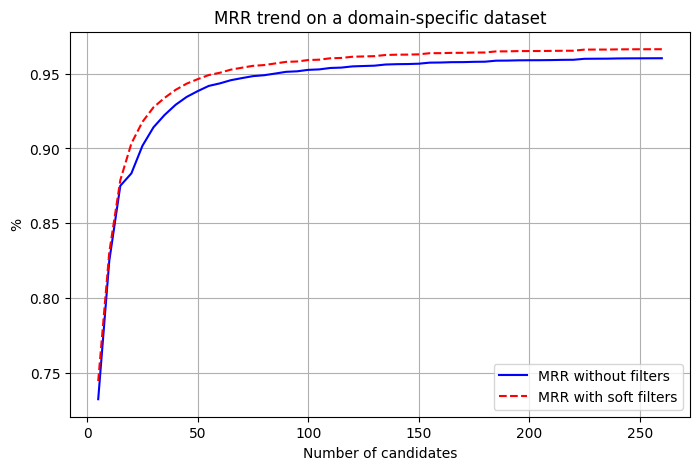

In [96]:
import matplotlib.pyplot as plt

# Extract x and y values
x_values = list(cov_mrr_values.keys())
y_values = [el[1] for el in cov_mrr_values_no_filter.values()]
y_values_filters = [el[1] for el in list(cov_mrr_values.values())]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, linestyle='-', color='b', label='MRR without filters')
plt.plot(x_values, y_values_filters, linestyle='--', color='r', label='MRR with soft filters')

# Labels and title
plt.xlabel("Number of candidates")
plt.ylabel("%")
plt.title("MRR trend on a domain-specific dataset")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

## Extended WD type vs WD type

In [14]:
# for each WD type inserted from the user (WD_query_type taken from CEA) now we retrieve the extended WD types until the root
# given the list of the ext_types we do the overlap with the ext_types taken from lamAPI with HARD and SOFT query

ext_query_types = []

for entity_id, type_str in WD_query_type.items():
    #print(f"{type_str}: {get_type_id(type_str)}")
    
    entity_name = key_to_cell[list(WD_query_type.keys())[0]]
    ext_query_types += list(set(retrieve_superclasses(get_type_id(type_str))))
    
    # query a lamapi dove specifico nel filtro il tipo

    # entity_id è il ground truth
    WD_candidate_types = WD_types(entity_id)  # WD_types() interroga il servizio types() ma forse è sbagliato (da implementare lato server non client)
print(ext_query_types)


KeyboardInterrupt: 

In [15]:
ext_query_types

['Q53617489',
 'Q98119401',
 'Q16334295',
 'Q20937557',
 'Q2897903',
 'Q2217301',
 'Q7725310',
 'Q1002697',
 'Q117208263',
 'Q732577',
 'Q24229398',
 'Q16887380',
 'Q15621286',
 'Q11032',
 'Q1554231',
 'Q106668099',
 'Q99527517',
 'Q43229',
 'Q3523102',
 'Q286583',
 'Q1193236',
 'Q121182',
 'Q61961344',
 'Q7048977',
 'Q58415929',
 'Q1639378',
 'Q49848',
 'Q28877',
 'Q2424752',
 'Q131085629',
 'Q488383',
 'Q58778',
 'Q117208269',
 'Q12774177',
 'Q35825432',
 'Q115668308',
 'Q854457',
 'Q26907166',
 'Q17538423',
 'Q31464082',
 'Q16686448',
 'Q107435521',
 'Q47461344',
 'Q37866906',
 'Q17172633',
 'Q106559804',
 'Q28314507',
 'Q386724',
 'Q17537576',
 'Q119648442',
 'Q234460',
 'Q5127848',
 'Q35120',
 'Q17489659',
 'Q340169',
 'Q16334298',
 'Q1261026',
 'Q16889133',
 'Q103940464',
 'Q11033',
 'Q11474',
 'Q53617489',
 'Q53617407',
 'Q193395',
 'Q28555911',
 'Q2897903',
 'Q9158768',
 'Q6671777',
 'Q10683158',
 'Q251473',
 'Q99527517',
 'Q96791170',
 'Q337060',
 'Q8205328',
 'Q104450446',
 '

## WD type vs NER type

In [ ]:
# for each WD type inserted from the user (WD_WD_query_type taken from CEA) now we retrieve the extended WD types until the root
# given the list of the ext_types we do the overlap with the ext_types taken from lamAPI with HARD and SOFT query

False

In [25]:
retrieve_superclasses("Q12299841")

{'Q12299841': 'cricketer',
 'Q2066131': 'athlete',
 'Q18536342': 'competitive player',
 'Q50995749': 'sportsperson',
 'Q4197743': 'player',
 'Q215627': 'person',
 'Q830077': 'subject',
 'Q795052': 'individual',
 'Q3778211': 'legal person',
 'Q53617489': 'independent continuant',
 'Q7239': 'organism',
 'Q24229398': 'agent',
 'Q106559804': 'person or organization',
 'Q103940464': 'continuant',
 'Q223557': 'physical object',
 'Q66394244': 'physical anatomical entity',
 'Q4406616': 'concrete object',
 'Q53617407': 'material entity',
 'Q27043950': 'anatomical entity',
 'Q488383': 'object',
 'Q35120': 'entity'}

In [8]:
cta_values_dict

{'58891288_0_1117541047012405958 1': 'http://dbpedia.org/ontology/Film',
 '8468806_0_4382447409703007384 1': 'http://dbpedia.org/ontology/Lake',
 '50245608_0_871275842592178099 0': 'http://dbpedia.org/ontology/Film',
 '14067031_0_559833072073397908 1': 'http://dbpedia.org/ontology/Language',
 '8286121_0_8471791395229161598 0': 'http://dbpedia.org/ontology/Country',
 '39759273_0_1427898308030295194 1': 'http://dbpedia.org/ontology/Film',
 '14380604_4_3329235705746762392 1': 'http://dbpedia.org/ontology/Company',
 '20135078_0_7570343137119682530 3': 'http://dbpedia.org/ontology/Person',
 '29414811_6_8221428333921653560 1': 'http://dbpedia.org/ontology/VideoGame',
 '34041816_1_4749054164534706977 2': 'http://dbpedia.org/ontology/City',
 '14067031_0_559833072073397908 7': 'http://dbpedia.org/ontology/Currency',
 '71137051_0_8039724067857124984 0': 'http://dbpedia.org/ontology/Bird',
 '29414811_2_4773219892816395776 1': 'http://dbpedia.org/ontology/VideoGame',
 '99070098_0_20748727413026969

In [11]:
cea_values_dict

{'50245608_0_871275842592178099 0': 'https://www.wikidata.org/entity/Q46551',
 '22864497_0_8632623712684511496 0': 'https://www.wikidata.org/entity/Q6738126',
 '66009064_0_9148652238372261251 0': 'https://www.wikidata.org/entity/Q1094988',
 '21362676_0_6854186738074119688 1': 'https://www.wikidata.org/entity/Q463832',
 '40534006_0_4617468856744635526 1': 'https://www.wikidata.org/entity/Q452590',
 '36102169_0_7739454799295072814 2': 'https://www.wikidata.org/entity/Q1978200',
 '53822652_0_5767892317858575530 1': 'https://www.wikidata.org/entity/Q200396',
 '60319454_0_3938426910282115527 0': 'https://www.wikidata.org/entity/Q69581',
 '8468806_0_4382447409703007384 1': 'https://www.wikidata.org/entity/Q1546823',
 '33401079_0_9127583903019856402 0': 'https://www.wikidata.org/entity/Q154538',
 '99070098_0_2074872741302696997 1': 'https://www.wikidata.org/entity/Q4920755',
 '50270082_0_444360818941411589 1': 'https://www.wikidata.org/entity/Q114468',
 '29414811_12_251152470253168163 1': 'ht